## Trabajo Práctico N°2

### **Análisis Exploratorio de Datos (EDA)**
##### ¿Qué características diferencian mejor a los distintos géneros?



In [61]:
import pandas as pd

# Cargar los datos
df = pd.read_csv("train.csv")

print("Filas y columnas:", df.shape)
display(df.head())


Filas y columnas: (4200, 17)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4,rock,2423


In [62]:
# Resumen por columna
display(pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isna().sum(),
    "valores_distintos": df.nunique()
}))

# Mostramos las etiquetas, incluidos los espacios
display(df["Expected"].map(repr).value_counts())


,tipo,nulos,valores_distintos
popularity,int64,0,93
duration_ms,int64,0,3147
explicit,bool,0,2
danceability,float64,0,737
energy,float64,0,1129
key,int64,0,12
loudness,float64,0,3005
mode,int64,0,2
speechiness,float64,0,849
acousticness,float64,0,1508


Expected
'jazz'          700
'electronic'    700
'hip-hop'       700
'rock'          700
'classical'     700
'acoustic'      700
Name: count, dtype: int64

### Cantidad de géneros y balance de clases

Contamos las observaciones de cada género y su porcentaje. Primero identificamos etiquetas nulas, vacías o compuestas solo por espacios, para no confundirlas con un género. Este análisis no modifica `df` ni imputa etiquetas.


In [63]:
# Separar las filas sin genero
sin_genero = df["Expected"].fillna("").str.strip().eq("")
filas_sin_genero = df[sin_genero].copy()
df_etiquetado = df[~sin_genero].copy()

print("Filas excluidas:", len(filas_sin_genero))
print("Filas con etiqueta:", len(df_etiquetado))


Filas excluidas: 0
Filas con etiqueta: 4200


In [64]:
# Cantidad y porcentaje de cada genero
balance_generos = df_etiquetado["Expected"].value_counts().to_frame("cantidad")
balance_generos["porcentaje"] = (
    balance_generos["cantidad"] / len(df_etiquetado) * 100
).round(2)

print("Cantidad de generos:", len(balance_generos))
display(balance_generos)


Cantidad de generos: 6


,cantidad,porcentaje
Expected,,
jazz,700,16.67
electronic,700,16.67
hip-hop,700,16.67
rock,700,16.67
classical,700,16.67
acoustic,700,16.67


Hay seis géneros con 700 observaciones cada uno. Cada género representa aproximadamente el 16,67 % del conjunto, por lo que las clases están balanceadas.


In [65]:
# Comparar filas sin contar el identificador
sin_id = df_etiquetado.drop(columns="Id")
caracteristicas = sin_id.drop(columns="Expected")

print("Mismas caracteristicas y mismo expected:", sin_id.duplicated().sum())
print("Mismas caracteristicas, sin considerar expected:", caracteristicas.duplicated().sum())

# Contar los géneros distintos dentro de cada grupo de características iguales
generos_por_grupo = sin_id.groupby(list(caracteristicas.columns))["Expected"].nunique()
print("Grupos con características iguales y géneros distintos:", (generos_por_grupo > 1).sum())

# Mostrar una fila por grupo, con los géneros asociados
grupos = sin_id.groupby(list(caracteristicas.columns))["Expected"].unique()
grupos_conflictivos = grupos[grupos.str.len() > 1].reset_index()
display(grupos_conflictivos)


Mismas caracteristicas y mismo expected: 663
Mismas caracteristicas, sin considerar expected: 680
Grupos con características iguales y géneros distintos: 17


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected
0,0,79000,False,0.797,0.415,5,-14.557,0,0.0514,0.8810,0.000000,0.0873,0.9650,113.420,3,"[classical, jazz]"
1,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.7880,0.000000,0.1460,0.6640,145.363,4,"[acoustic, rock]"
2,0,133506,False,0.548,0.412,5,-10.248,1,0.0333,0.8070,0.934000,0.1270,0.3250,79.512,4,"[jazz, classical]"
3,0,200360,False,0.541,0.321,5,-14.418,1,0.0329,0.7140,0.003450,0.1010,0.5490,133.537,4,"[classical, jazz]"
4,0,216386,False,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.5150,140.182,4,"[acoustic, rock]"
5,0,242520,False,0.696,0.448,8,-9.099,1,0.0333,0.4520,0.000024,0.0904,0.5690,95.004,4,"[electronic, rock]"
6,0,256293,False,0.445,0.278,10,-11.882,0,0.0313,0.9140,0.005770,0.1010,0.2620,99.058,3,"[jazz, classical]"
7,1,181600,False,0.568,0.396,8,-13.921,1,0.0290,0.7380,0.159000,0.1160,0.5780,136.489,4,"[jazz, classical]"
8,1,302346,False,0.755,0.454,9,-9.609,0,0.0352,0.7570,0.000000,0.2360,0.3300,120.060,4,"[rock, acoustic]"
9,43,194194,False,0.534,0.213,1,-8.640,1,0.0283,0.8840,0.000000,0.1070,0.0998,98.385,4,"[acoustic, jazz]"


Podemos ver que muchas filas tienen las mismas características: hay 663 repeticiones con el mismo género y 680 sin considerar el género, contando las apariciones adicionales a la primera. Además, existen 17 grupos de características idénticas asociados a géneros distintos. Por lo tanto, no todas las repeticiones tienen etiquetas diferentes.


### Resumen de las variables numéricas


In [66]:
numericas = ["popularity", "duration_ms", "danceability", "energy", "loudness",
            "speechiness", "acousticness", "instrumentalness", "liveness",
            "valence", "tempo"]

display(df_etiquetado[numericas].describe().T.round(3))


,count,mean,std,min,25%,50%,75%,max
popularity,4199.0,28.375,27.612,0.000,0.000,28.000,55.000,92.000
duration_ms,4199.0,216630.866,109056.042,17453.000,165973.500,203891.000,247080.000,2646866.000
danceability,4199.0,0.560,0.173,0.000,0.444,0.571,0.689,0.959
energy,4199.0,0.506,0.271,0.001,0.278,0.530,0.737,0.997
loudness,4199.0,-10.190,6.447,-41.531,-12.472,-8.186,-5.772,-0.927
speechiness,4199.0,0.068,0.072,0.000,0.034,0.043,0.065,0.905
acousticness,4199.0,0.462,0.376,0.000,0.075,0.416,0.852,0.996
instrumentalness,4199.0,0.170,0.326,0.000,0.000,0.000,0.076,0.978
liveness,4199.0,0.175,0.136,0.018,0.098,0.121,0.209,0.962
valence,4199.0,0.460,0.249,0.000,0.250,0.446,0.650,0.980


### Relaciones entre características por género

Cada punto representa una observación y su color indica el género.

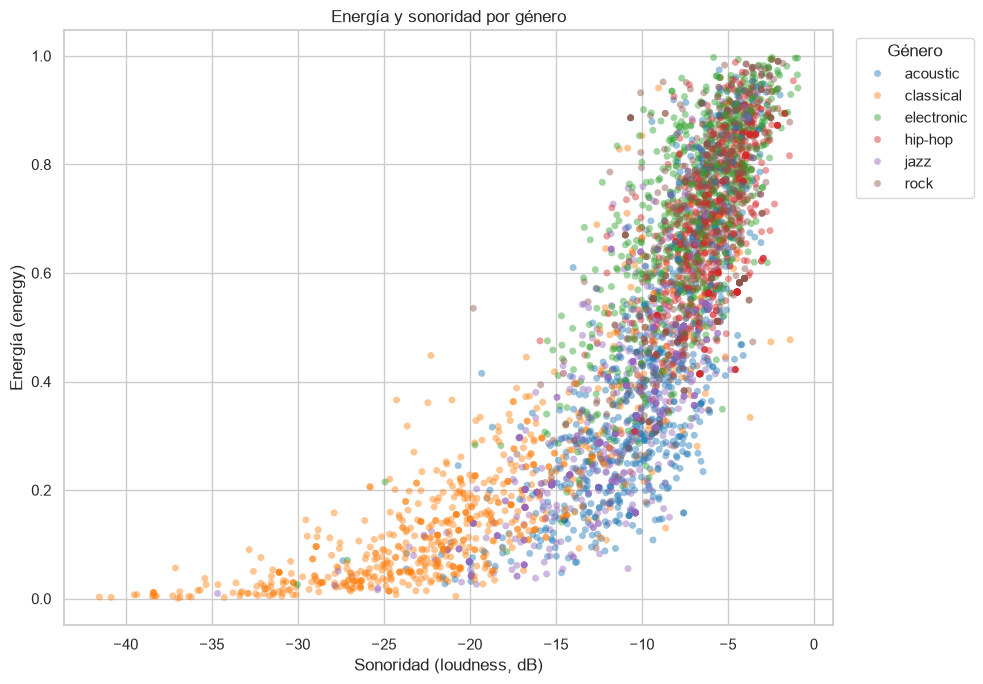

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
generos = sorted(df_etiquetado["Expected"].unique())

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_etiquetado, x="loudness", y="energy",
                hue="Expected", hue_order=generos, palette="tab10",
                alpha=0.45, s=25, linewidth=0)
plt.title("Energía y sonoridad por género")
plt.xlabel("Sonoridad (loudness, dB)")
plt.ylabel("Energía (energy)")
plt.legend(title="Género", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


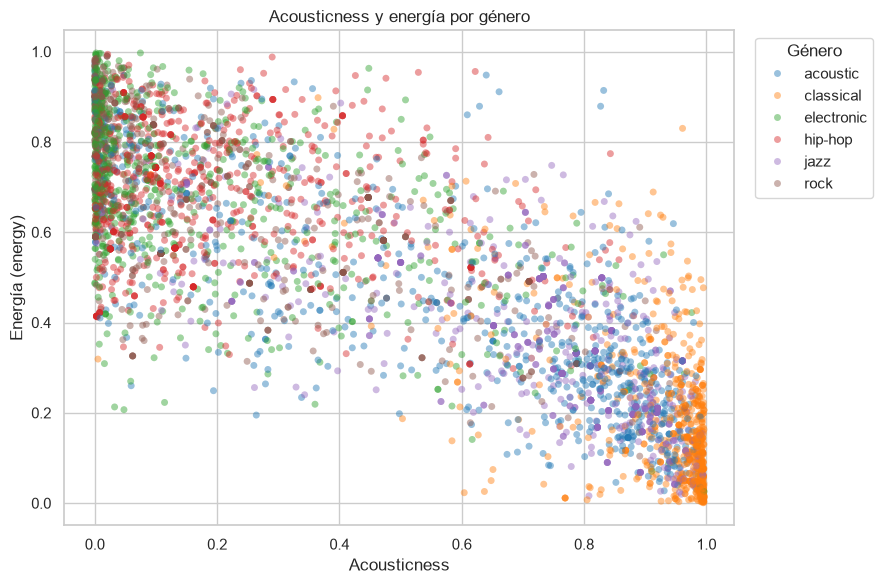

In [77]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_etiquetado, x="acousticness", y="energy",
                hue="Expected", hue_order=generos, palette="tab10",
                alpha=0.45, s=25, linewidth=0)
plt.title("Acousticness y energía por género")
plt.xlabel("Acousticness")
plt.ylabel("Energía (energy)")
plt.legend(title="Género", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


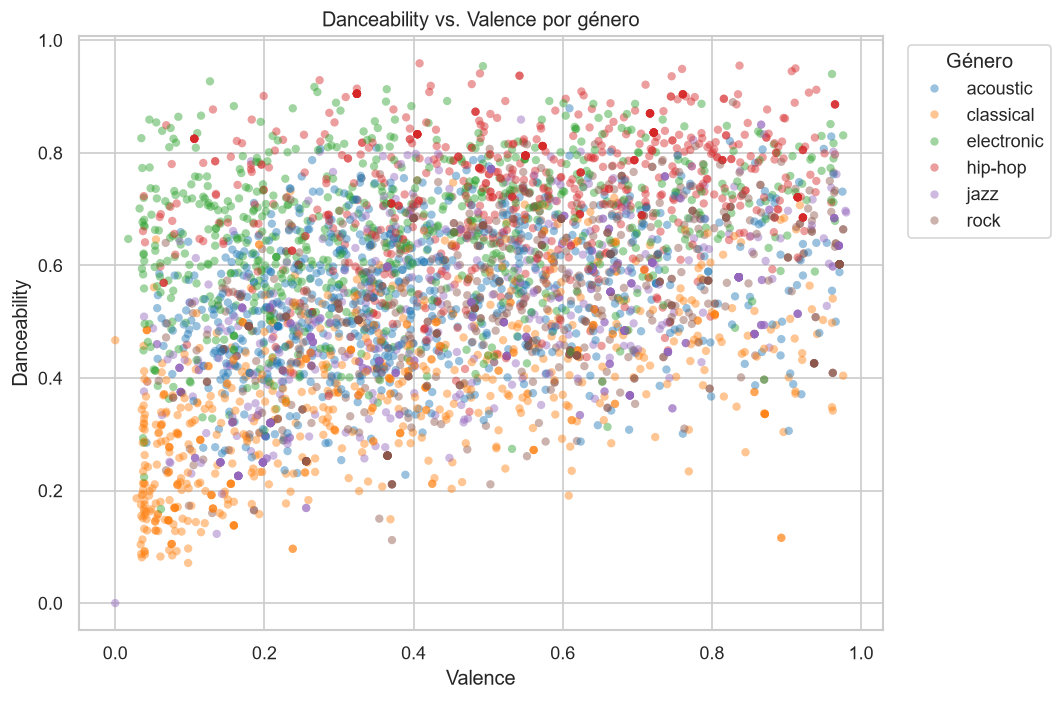

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_etiquetado, x="valence", y="danceability",
                hue="Expected", hue_order=generos, palette="tab10",
                alpha=0.45, s=25, linewidth=0)
plt.title("Danceability vs. Valence por género")
plt.xlabel("Valence")
plt.ylabel("Danceability")
plt.legend(title="Género", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
